Saving insurance.csv to insurance (3).csv
    Model         RMSE        R2
0  Linear  5796.284659  0.783593
1   Lasso  5796.649551  0.783566
2   Ridge  5796.979691  0.783541


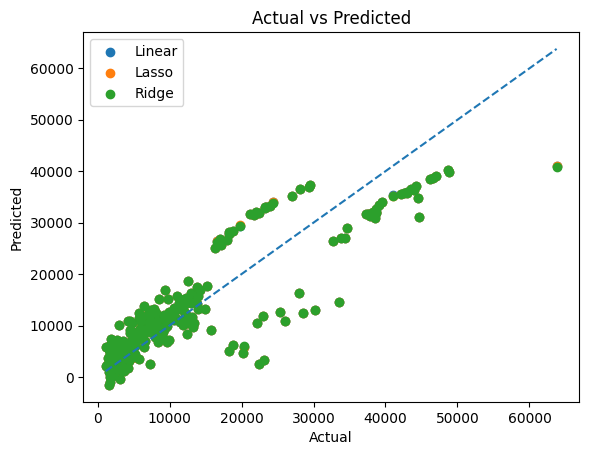

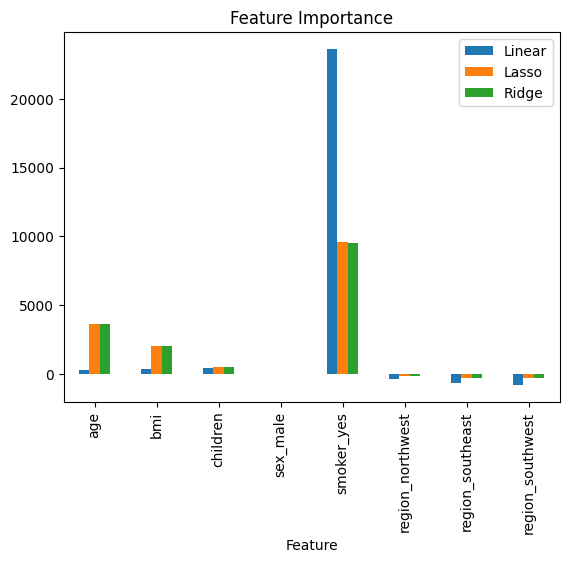

In [8]:
# ============================================
# WITHOUT HYPERPARAMETER TUNING (WITH GRAPHS)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 1. Load Dataset
# ===============================

from google.colab import files
files.upload()

df = pd.read_csv('insurance.csv')

df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']

# ===============================
# 2. Train Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 3. Models (Default)
# ===============================

lin = LinearRegression()
lasso = Lasso()
ridge = Ridge()

lin.fit(X_train, y_train)
lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)

y_lin = lin.predict(X_test)
y_lasso = lasso.predict(X_test_scaled)
y_ridge = ridge.predict(X_test_scaled)

# ===============================
# 4. Evaluation
# ===============================

def eval(y, pred):
    return np.sqrt(mean_squared_error(y, pred)), r2_score(y, pred)

rmse_lin, r2_lin = eval(y_test, y_lin)
rmse_lasso, r2_lasso = eval(y_test, y_lasso)
rmse_ridge, r2_ridge = eval(y_test, y_ridge)

results = pd.DataFrame({
    "Model": ["Linear", "Lasso", "Ridge"],
    "RMSE": [rmse_lin, rmse_lasso, rmse_ridge],
    "R2": [r2_lin, r2_lasso, r2_ridge]
})

print(results)

# ===============================
# 5. GRAPH (Actual vs Predicted)
# ===============================

plt.figure()

plt.scatter(y_test, y_lin, label="Linear")
plt.scatter(y_test, y_lasso, label="Lasso")
plt.scatter(y_test, y_ridge, label="Ridge")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# ===============================
# 6. FEATURE IMPORTANCE
# ===============================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lin.coef_,
    "Lasso": lasso.coef_,
    "Ridge": ridge.coef_
})

coef_df.set_index("Feature").plot(kind='bar')
plt.title("Feature Importance")
plt.xticks(rotation=90)
plt.show()

Saving insurance.csv to insurance (4).csv
         Model         RMSE        R2
0       Linear  5796.284659  0.783593
1  Lasso Tuned  5835.803276  0.780632
2  Ridge Tuned  5802.527042  0.783127


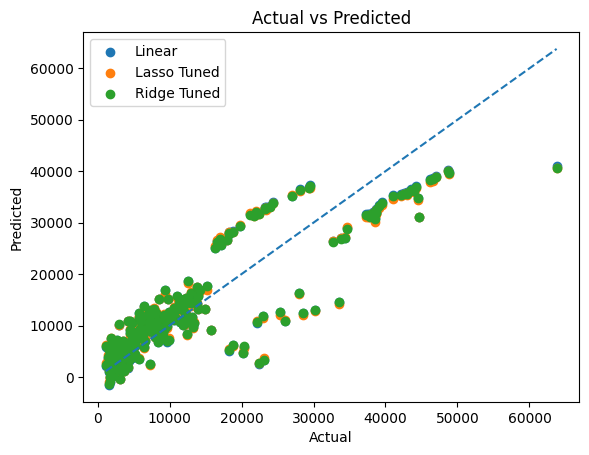

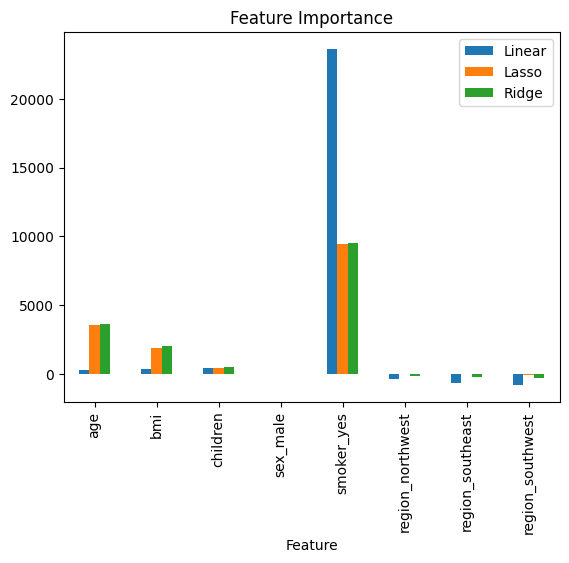

In [9]:
# ============================================
# WITH HYPERPARAMETER TUNING (WITH GRAPHS)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 1. Load Dataset
# ===============================

from google.colab import files
files.upload()

df = pd.read_csv('insurance.csv')

df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']

# ===============================
# 2. Train Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 3. Models (Tuned)
# ===============================

lin = LinearRegression()

lasso = LassoCV(alphas=np.logspace(-3, 2, 50), cv=5)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)

lin.fit(X_train, y_train)
lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)

y_lin = lin.predict(X_test)
y_lasso = lasso.predict(X_test_scaled)
y_ridge = ridge.predict(X_test_scaled)

# ===============================
# 4. Evaluation
# ===============================

def eval(y, pred):
    return np.sqrt(mean_squared_error(y, pred)), r2_score(y, pred)

rmse_lin, r2_lin = eval(y_test, y_lin)
rmse_lasso, r2_lasso = eval(y_test, y_lasso)
rmse_ridge, r2_ridge = eval(y_test, y_ridge)

results = pd.DataFrame({
    "Model": ["Linear", "Lasso Tuned", "Ridge Tuned"],
    "RMSE": [rmse_lin, rmse_lasso, rmse_ridge],
    "R2": [r2_lin, r2_lasso, r2_ridge]
})

print(results)

# ===============================
# 5. GRAPH
# ===============================

plt.figure()

plt.scatter(y_test, y_lin, label="Linear")
plt.scatter(y_test, y_lasso, label="Lasso Tuned")
plt.scatter(y_test, y_ridge, label="Ridge Tuned")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# ===============================
# 6. FEATURE IMPORTANCE
# ===============================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lin.coef_,
    "Lasso": lasso.coef_,
    "Ridge": ridge.coef_
})

coef_df.set_index("Feature").plot(kind='bar')
plt.title("Feature Importance")
plt.xticks(rotation=90)
plt.show()